## Install dependencies

In [ ]:
!pip install rfdetr supervision roboflow

In [ ]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

In [ ]:
!pip list

In [ ]:
import sys

# 1. Uninstall the "Edge" version (5.0.0) that is causing the crash
# We also uninstall sentence-transformers to start clean
print("⏳ Removing incompatible versions...")
!{sys.executable} -m pip uninstall -y transformers sentence-transformers

# 2. Install the "Stable" versions from Colab
# This downgrades transformers to the one that still has the required functions
print("⏳ Installing matching Colab versions...")
!{sys.executable} -m pip install transformers==4.57.6 sentence-transformers==5.2.0

## Checking GPU availability

In [1]:
!nvidia-smi

Fri Jan 30 01:10:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 591.44                 Driver Version: 591.44         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4060 Ti   WDDM  |   00000000:01:00.0  On |                  N/A |
|  0%   38C    P0             11W /  160W |     687MiB /   8188MiB |      1%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import torch
import os
import supervision as sv
from roboflow import Roboflow

# Check if CUDA (NVIDIA GPU support) is available
if torch.cuda.is_available():
  print(f"✅ GPU Found: {torch.cuda.get_device_name(0)}")
  print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")
else:
  print("❌ GPU not found. Training will be very slow on CPU.")

✅ GPU Found: NVIDIA GeForce RTX 4060 Ti
Memory: 8.00 GB


## Import annotated dataset from roboflow project

In [3]:
from dotenv import load_dotenv
load_dotenv()
api_key = os.getenv("ROBOFLOW_API_KEY")
rf = Roboflow(api_key=api_key)
project = rf.workspace("tanwa-workspace").project("sidewalk-segmentation-wj5dv")
version = project.version(6)
dataset = version.download("coco-segmentation")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Sidewalk-segmentation-6 in coco-segmentation:: 100%|██████████| 785/785 [00:00<00:00, 2104.73it/s]


In [3]:
import os
import torch
from rfdetr import RFDETRSegMedium

print("Loading RF-DETR Segmentation (Medium)...")
model = RFDETRSegMedium()

Loading RF-DETR Segmentation (Medium)...
Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 12 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights


## Train model

In [2]:
found_path = r"C:\Users\Tanwa\Documents\Tanwa\Project_Resource\Sidewalk-segmentation-6"
dataset_dir=found_path

In [5]:
import os
import time
from datetime import timedelta

if found_path:
  BATCH_SIZE = 2
  EPOCHS = 30
  GRAD_ACCUM_STEPS = 8

  print(f"Training on {torch.cuda.get_device_name(0)}...")

  start_time = time.time()

  model.train(
    dataset_dir=found_path,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    grad_accum_steps=GRAD_ACCUM_STEPS,
    device="cuda",  
    num_workers=0
  )
  elapsed = time.time() - start_time
        
  print("TRAINING COMPLETE")
  print(f"Total Time Used: {str(timedelta(seconds=int(elapsed)))}")

  # Save
  print("Done.")
else:
  print("Error: Could not find 'train/_annotations.coco.json' anywhere inside Project Resource.")
  print("Please check if you unzipped the dataset correctly.")

Training on NVIDIA GeForce RTX 4060 Ti...
TensorBoard logging initialized. To monitor logs, use 'tensorboard --logdir output' and open http://localhost:6006/ in browser.
Not using distributed mode
git:
  sha: N/A, status: clean, branch: N/A

Namespace(num_classes=7, grad_accum_steps=8, amp=True, lr=0.0001, lr_encoder=0.00015, batch_size=2, weight_decay=0.0001, epochs=30, lr_drop=100, clip_max_norm=0.1, lr_vit_layer_decay=0.8, lr_component_decay=0.7, do_benchmark=False, dropout=0, drop_path=0.0, drop_mode='standard', drop_schedule='constant', cutoff_epoch=0, pretrained_encoder=None, pretrain_weights='rf-detr-seg-medium.pt', pretrain_exclude_keys=None, pretrain_keys_modify_to_load=None, pretrained_distiller=None, encoder='dinov2_windowed_small', vit_encoder_num_layers=12, window_block_indexes=None, position_embedding='sine', out_feature_indexes=[3, 6, 9, 12], freeze_encoder=False, layer_norm=True, rms_norm=False, backbone_lora=False, force_no_pretrain=False, dec_layers=5, dim_feedforward

torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\TensorShape.cpp:3596.)


Epoch: [0]  [ 0/41]  eta: 0:03:40  lr: 0.000100  class_error: 79.23  loss: 138.5849 (138.5849)  loss_ce: 3.7789 (3.7789)  loss_bbox: 3.9234 (3.9234)  loss_giou: 2.1549 (2.1549)  loss_mask_ce: 7.4671 (7.4671)  loss_mask_dice: 3.6093 (3.6093)  loss_ce_0: 2.7257 (2.7257)  loss_bbox_0: 3.9044 (3.9044)  loss_giou_0: 2.1430 (2.1430)  loss_mask_ce_0: 9.6574 (9.6574)  loss_mask_dice_0: 3.8170 (3.8170)  loss_ce_1: 3.4785 (3.4785)  loss_bbox_1: 3.8001 (3.8001)  loss_giou_1: 2.0802 (2.0802)  loss_mask_ce_1: 11.6757 (11.6757)  loss_mask_dice_1: 3.7473 (3.7473)  loss_ce_2: 3.6641 (3.6641)  loss_bbox_2: 3.9014 (3.9014)  loss_giou_2: 2.0675 (2.0675)  loss_mask_ce_2: 11.4052 (11.4052)  loss_mask_dice_2: 3.7575 (3.7575)  loss_ce_3: 3.7453 (3.7453)  loss_bbox_3: 4.0082 (4.0082)  loss_giou_3: 2.1511 (2.1511)  loss_mask_ce_3: 8.4590 (8.4590)  loss_mask_dice_3: 3.7082 (3.7082)  loss_ce_enc: 3.3244 (3.3244)  loss_bbox_enc: 3.8644 (3.8644)  loss_giou_enc: 2.1319 (2.1319)  loss_mask_ce_enc: 10.7628 (10.7628) 

Mean of empty slice
Mean of empty slice
Mean of empty slice


Test:  [ 0/30]  eta: 0:00:15  class_error: 30.00  loss: 38.9149 (38.9149)  loss_ce: 4.5938 (4.5938)  loss_bbox: 0.1569 (0.1569)  loss_giou: 0.3364 (0.3364)  loss_mask_ce: 0.3368 (0.3368)  loss_mask_dice: 0.6397 (0.6397)  loss_ce_0: 5.1875 (5.1875)  loss_bbox_0: 0.2004 (0.2004)  loss_giou_0: 0.4291 (0.4291)  loss_mask_ce_0: 0.3730 (0.3730)  loss_mask_dice_0: 0.8214 (0.8214)  loss_ce_1: 5.0000 (5.0000)  loss_bbox_1: 0.2105 (0.2105)  loss_giou_1: 0.3493 (0.3493)  loss_mask_ce_1: 0.2978 (0.2978)  loss_mask_dice_1: 0.6065 (0.6065)  loss_ce_2: 4.7188 (4.7188)  loss_bbox_2: 0.1931 (0.1931)  loss_giou_2: 0.3391 (0.3391)  loss_mask_ce_2: 0.2611 (0.2611)  loss_mask_dice_2: 0.5460 (0.5460)  loss_ce_3: 4.7500 (4.7500)  loss_bbox_3: 0.1949 (0.1949)  loss_giou_3: 0.3102 (0.3102)  loss_mask_ce_3: 0.2876 (0.2876)  loss_mask_dice_3: 0.6070 (0.6070)  loss_ce_enc: 5.0625 (5.0625)  loss_bbox_enc: 0.3293 (0.3293)  loss_giou_enc: 0.4906 (0.4906)  loss_mask_ce_enc: 0.4317 (0.4317)  loss_mask_dice_enc: 0.8540

## Compare annotated images to predicted images from model

### Create annotated image visualization from dataset

In [3]:
import json
import os
import cv2
import numpy as np
import random

JSON_PATH = os.path.join(dataset_dir, "test", "_annotations.coco.json")
IMAGES_DIR = os.path.join(dataset_dir, "test")
OUTPUT_FOLDER = "step1_ground_truth_custom_colors"
NUM_IMAGES = 10

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# 1. Load Data
print(f"Reading JSON from: {JSON_PATH}")
with open(JSON_PATH, 'r') as f:
  coco_data = json.load(f)

# 2. Define Custom Colors
class_colors = {
  1: (0, 255, 255),    # Obstacle: Yellow
  2: (0, 165, 255),    # Road: Orange
  3: (255, 255, 0),    # Sidewalk Structure: Cyan
  4: (255, 0, 255),    # Surface Damage: Magenta
  5: (0, 0, 255),      # Vehicle: Red
  6: (255, 0, 128),    # Walkable Path: Purple
}
DRAW_ORDER = {
  2: 0,   # Road (Background)
  3: 1,   # Sidewalk Structure (Background)
  6: 2,   # Walkable Path (Midground)
  5: 3,   # Vehicle (Foreground)
  4: 4,   # Surface Damage (Critical Foreground)
  1: 5    # Obstacle (Critical Foreground)
}

category_map = {cat['id']: cat['name'] for cat in coco_data['categories']}
print(f"Category Mapping: {category_map}")

# 3. Setup Annotations Map
annotations_map = {}
for ann in coco_data['annotations']:
  img_id = ann['image_id']
  if img_id not in annotations_map:
    annotations_map[img_id] = []
  if 'segmentation' in ann and len(ann['segmentation']) > 0:
    annotations_map[img_id].append(ann)

# 4. Map Image IDs to Filenames
image_map = {img['id']: img['file_name'] for img in coco_data['images']}

# 5. Pick Images
all_files = [f for f in os.listdir(IMAGES_DIR) if f.lower().endswith(('.jpg', '.png'))]
valid_files = [f for f in all_files if any(os.path.basename(json_name) == f for json_name in image_map.values())]
random.seed()
SELECTED_IMAGES = random.sample(valid_files, min(NUM_IMAGES, len(valid_files)))

print(f"Processing {len(SELECTED_IMAGES)} images...")

# 6. Draw Masks
for filename in SELECTED_IMAGES:
  # Find ID
  target_id = None
  for img_id, json_filename in image_map.items():
    if os.path.basename(json_filename) == filename:
      target_id = img_id
      break
  if target_id is None: continue

  # Load Image
  image_path = os.path.join(IMAGES_DIR, filename)
  image = cv2.imread(image_path)
  if image is None: continue
  
  overlay = image.copy()
  active_classes = set()

  if target_id in annotations_map:
    anns = annotations_map[target_id]
    
    # --- NEW: SORT ANNOTATIONS BY DRAW_ORDER ---
    # We sort the annotations list so that Background IDs appear first
    anns.sort(key=lambda x: DRAW_ORDER.get(x['category_id'], 99))
    
    for ann in anns:
      cat_id = ann['category_id']
      poly = ann['segmentation']
      
      color = class_colors.get(cat_id, (255, 255, 255))
      class_name = category_map.get(cat_id, f"Class {cat_id}")
      active_classes.add((class_name, color))
      
      # Draw
      for p in poly:
        # Ensure points are integers and reshaped correctly for OpenCV
        pts = np.array(p).reshape((-1, 1, 2)).astype(np.int32)
        
        # Because the list is sorted, 'Obstacle' will be drawn 
        # AFTER 'Road', correctly appearing on top.
        cv2.fillPoly(overlay, [pts], color)
        cv2.polylines(image, [pts], True, (255, 255, 255), 1)

  # Blend (Transparency)
  alpha = 0.5
  cv2.addWeighted(overlay, alpha, image, 1 - alpha, 0, image)
  
  # Draw Legend
  legend_y = 30
  cv2.putText(image, "Ground Truth:", (10, legend_y), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
  legend_y += 30
  
  # Sort classes by name for neatness
  for cls_name, color in sorted(list(active_classes)):
    # Box
    cv2.rectangle(image, (10, legend_y - 15), (30, legend_y + 5), color, -1)
    cv2.rectangle(image, (10, legend_y - 15), (30, legend_y + 5), (255, 255, 255), 1)
    # Text
    cv2.putText(image, cls_name, (40, legend_y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
    legend_y += 25

  # Save
  save_path = os.path.join(OUTPUT_FOLDER, f"gt_colored_{filename}")
  cv2.imwrite(save_path, image)
  print(f"Saved at: {save_path}")

print(f"Done! Check the folder '{OUTPUT_FOLDER}'.")

Reading JSON from: C:\Users\Tanwa\Documents\Tanwa\Project_Resource\Sidewalk-segmentation-6\test\_annotations.coco.json
Category Mapping: {0: 'objects', 1: 'obstacle', 2: 'road', 3: 'sidewalk_structure', 4: 'surface_damage', 5: 'vehicle', 6: 'walkable_path'}
Processing 10 images...
Saved at: step1_ground_truth_custom_colors\gt_colored_13-820799_100-564390_SIUP0T7UwupMibiRb1KnUw_300_2025-09_jpg.rf.ef08dd1c87d4b98c5af1fcadc85d981c.jpg
Saved at: step1_ground_truth_custom_colors\gt_colored_13-868009_100-592167_IgPvcBgkHTQcUc3t38q96A_300_2025-08_jpg.rf.458a46f04b25933c15ecdb2bdc0b37ac.jpg
Saved at: step1_ground_truth_custom_colors\gt_colored_13-786364_100-547131_g9gnWYhvoSUPIvFNi48Sow_109_2024-11_jpg.rf.22becb25060f83362441a643efa2addc.jpg
Saved at: step1_ground_truth_custom_colors\gt_colored_13-842121_100-576897_NFtbAccCi8S72JXYa1VXHA_301_2025-08_jpg.rf.5abdf8eb4b440a88c284c4dffa97de3e.jpg
Saved at: step1_ground_truth_custom_colors\gt_colored_13-825556_100-567163_UP-5uZJUCHSZZ0Bc8os9dw_300_

### Use model to annotate same images

In [4]:
import os
import cv2
import json
import numpy as np
from PIL import Image
from rfdetr import RFDETRSegMedium
import datetime
import supervision as sv

# --- CONFIGURATION ---
CHECKPOINT_PATH = "output/checkpoint_best_ema.pth"
INPUT_FOLDER_GT = "step1_ground_truth_custom_colors" 
OUTPUT_JSON = "model_predictions.coco.json"
OUTPUT_IMAGE_DIR = "step2_visual_predictions"
CONFIDENCE_THRESHOLD = 0.35

os.makedirs(OUTPUT_IMAGE_DIR, exist_ok=True)

# Define Colors (Matching your preference)
class_colors = {
    1: (0, 255, 255),    # Obstacle: Yellow
    2: (0, 165, 255),    # Road: Orange
    3: (255, 255, 0),    # Sidewalk Structure: Cyan
    4: (255, 0, 255),    # Surface Damage: Magenta
    5: (0, 0, 255),      # Vehicle: Red
    6: (255, 0, 128),    # Walkable Path: Purple
}

DRAW_ORDER = {
    2: 0,   # Road (Background)
    3: 1,   # Sidewalk Structure (Background)
    6: 2,   # Walkable Path (Midground)
    5: 3,   # Vehicle (Foreground)
    4: 4,   # Surface Damage (Critical Foreground)
    1: 5    # Obstacle (Critical Foreground)
}

# 1. Load Original Data (To copy categories and file IDs)
json_path = os.path.join(dataset_dir, "test", "_annotations.coco.json")
with open(json_path, 'r') as f:
    original_coco = json.load(f)

filename_to_id = {img['file_name']: img['id'] for img in original_coco['images']}
cat_id_to_name = {cat['id']: cat['name'] for cat in original_coco['categories']}

# 2. Initialize New COCO Structure
new_coco = {
    "info": {
        "year": datetime.datetime.now().year,
        "version": "1.0",
        "description": "Model Predictions (RF-DETR)",
        "date_created": datetime.datetime.now().isoformat()
    },
    "licenses": original_coco.get("licenses", []),
    "categories": original_coco["categories"],
    "images": [],
    "annotations": []
}

# 3. Load Model
print(f"⏳ Loading Model...")
model = RFDETRSegMedium(pretrain_weights=CHECKPOINT_PATH)
model.optimize_for_inference()
print("✅ Model Ready.")

# 4. Run Inference
target_files = [f.replace("gt_colored_", "") for f in os.listdir(INPUT_FOLDER_GT) if f.startswith("gt_colored_")]
print(f"🚀 Processing {len(target_files)} images...")

annotation_id_counter = 1

for filename in target_files:
    image_path = os.path.join(dataset_dir, "test", filename)
    if not os.path.exists(image_path): continue
    
    # Load Image
    image_pil = Image.open(image_path).convert("RGB")
    image_bgr = cv2.cvtColor(np.array(image_pil), cv2.COLOR_RGB2BGR) # For drawing
    width, height = image_pil.size
    
    # Add Image Entry to JSON
    image_id = filename_to_id.get(filename, len(new_coco["images"]) + 1)
    new_coco["images"].append({
        "id": image_id, "file_name": filename, "width": width, "height": height, 
        "date_captured": datetime.datetime.now().isoformat()
    })

    # --- INFERENCE ---
    detections = model.predict(image_pil, threshold=CONFIDENCE_THRESHOLD)

    detection_indices = list(range(len(detections)))
    detection_indices.sort(key=lambda i: DRAW_ORDER.get(int(detections.class_id[i]), 99))
    
    # --- VISUALIZATION & DATA EXTRACTION ---
    overlay = image_bgr.copy()
    active_classes = set()

    if detections.mask is not None:
        # Loop through sorted indices instead of range(len(detections))
        for i in detection_indices:
            class_id = int(detections.class_id[i])
            mask = detections.mask[i]
            score = float(detections.confidence[i])
            bbox = detections.xyxy[i]
            
            # --- 1. VISUALIZATION PART ---
            color = class_colors.get(class_id, (255, 255, 255))
            class_name = cat_id_to_name.get(class_id, f"Class {class_id}")
            active_classes.add((class_name, color))
            
            mask_uint8 = (mask * 255).astype(np.uint8)
            contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            
            for contour in contours:
                # Drawing in this order ensures Obstacles (1) overlap Road (2)
                cv2.fillPoly(overlay, [contour], color)
                cv2.polylines(image_bgr, [contour], True, (255, 255, 255), 1)

                # --- 2. JSON DATA PART ---
                if len(contour) > 2:
                    segmentation = [contour.flatten().tolist()]
                    x1, y1, x2, y2 = bbox
                    bbox_coco = [float(x1), float(y1), float(x2 - x1), float(y2 - y1)]
                    
                    new_coco["annotations"].append({
                        "id": annotation_id_counter,
                        "image_id": image_id,
                        "category_id": class_id,
                        "bbox": bbox_coco,
                        "area": float(np.sum(mask)),
                        "segmentation": segmentation,
                        "iscrowd": 0,
                        "score": score
                    })
                    annotation_id_counter += 1

    # Finalize Visuals (Blend + Legend)
    alpha = 0.5
    cv2.addWeighted(overlay, alpha, image_bgr, 1 - alpha, 0, image_bgr)
    
    legend_y = 30
    cv2.putText(image_bgr, "AI Prediction:", (10, legend_y), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
    legend_y += 30
    
    for cls_name, color in sorted(list(active_classes)):
        cv2.rectangle(image_bgr, (10, legend_y - 15), (30, legend_y + 5), color, -1)
        cv2.rectangle(image_bgr, (10, legend_y - 15), (30, legend_y + 5), (255, 255, 255), 1)
        cv2.putText(image_bgr, cls_name, (40, legend_y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        legend_y += 25
        
    # Save Image
    save_img_path = os.path.join(OUTPUT_IMAGE_DIR, f"pred_{filename}")
    cv2.imwrite(save_img_path, image_bgr)
    print(f"   Processed: {filename} -> Saved JPG & JSON entries")

# 5. Save JSON
with open(OUTPUT_JSON, 'w') as f:
    json.dump(new_coco, f)

print(f"\n✅ SUCCESS!")
print(f"   1. Visuals saved to: '{OUTPUT_IMAGE_DIR}/'")
print(f"   2. Data saved to:    '{OUTPUT_JSON}'")

⏳ Loading Model...
Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 12 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


✅ Model Ready.
🚀 Processing 19 images...
   Processed: 13-766080_100-539098_ChQm2_wvnCcY3x2UUva65A_115_2024-11_jpg.rf.a668468063aeb2e740fc9b98b55d9a25.jpg -> Saved JPG & JSON entries
   Processed: 13-768277_100-540090_GKUK13WsMQk7vQakNfvBxg_298_2024-08_jpg.rf.430c55e856d3a48d9afb5711c9d52b0c.jpg -> Saved JPG & JSON entries
   Processed: 13-773685_100-542378_Xn86lbv5kM7QnId4Xtdb5A_290_2024-11_jpg.rf.f93de60cab5403df1f837460ef3aea1a.jpg -> Saved JPG & JSON entries
   Processed: 13-786364_100-547131_g9gnWYhvoSUPIvFNi48Sow_109_2024-11_jpg.rf.22becb25060f83362441a643efa2addc.jpg -> Saved JPG & JSON entries
   Processed: 13-802809_100-553983_eI5X9CEIng_swRhpFFWsHA_120_2025-09_jpg.rf.9928f5e4f89d9c10bf3bde4483e86544.jpg -> Saved JPG & JSON entries
   Processed: 13-805337_100-555499_ueLClBzVxiR5Ay0DwiMYcA_120_2025-09_jpg.rf.b2b17e50fa3b52e387b82b1778aa3b6d.jpg -> Saved JPG & JSON entries
   Processed: 13-807150_100-556594_x602eGzbYsq2IWNW2vbvxA_119_2025-09_jpg.rf.a44586693c4623a272e75750d45aa1

## Performance report

⏳ Loading Test Dataset...
✅ Loaded 60 images.
⏳ Loading Model...
Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 12 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights
🚀 Running Evaluation...
   Processed 1/60...
   Processed 6/60...
   Processed 11/60...
   Processed 16/60...
   Processed 21/60...
   Processed 26/60...
   Processed 31/60...
   Processed 36/60...
   Processed 41/60...
   Processed 46/60...
   Processed 51/60...
   Processed 56/60...

📊 Calculating Statistics...


<Figure size 1200x1000 with 0 Axes>

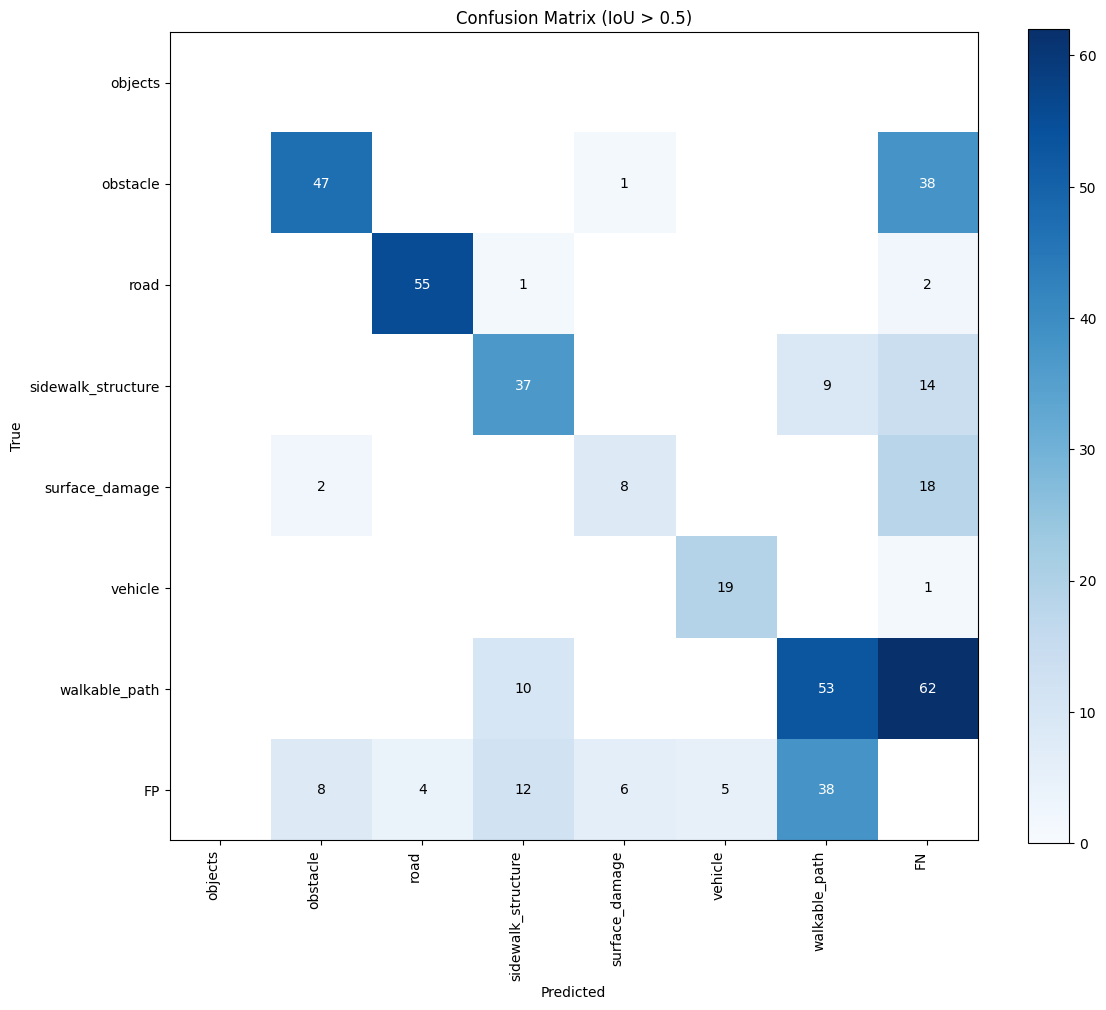


Class Name                | Precision  | Recall     | F1-Score  
------------------------------------------------------------
objects                   | 0.00       | 0.00       | 0.00
obstacle                  | 0.82       | 0.55       | 0.66
road                      | 0.93       | 0.95       | 0.94
sidewalk_structure        | 0.62       | 0.62       | 0.62
surface_damage            | 0.53       | 0.29       | 0.37
vehicle                   | 0.79       | 0.95       | 0.86
walkable_path             | 0.53       | 0.42       | 0.47
------------------------------------------------------------


In [5]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import supervision as sv
from rfdetr import RFDETRSegMedium
from PIL import Image

# --- CONFIGURATION ---
CHECKPOINT_PATH = "output/checkpoint_best_ema.pth"
CONFIDENCE_THRESHOLD = 0.5
IOU_THRESHOLD = 0.5 

# 1. Load Test Dataset
print("⏳ Loading Test Dataset...")
images_dir = os.path.join(dataset_dir, "test")
annotations_path = os.path.join(dataset_dir, "test", "_annotations.coco.json")

ds_test = sv.DetectionDataset.from_coco(
  images_directory_path=images_dir,
  annotations_path=annotations_path
)
print(f"✅ Loaded {len(ds_test)} images.")

# 2. Load Model
print("⏳ Loading Model...")
model = RFDETRSegMedium(pretrain_weights=CHECKPOINT_PATH)
model.optimize_for_inference()

# 3. Run Inference
print("🚀 Running Evaluation...")
predictions = []
targets = []

# FIX: We iterate the dataset directly. 
# It yields: (filename, image_as_numpy, detections)
for i, (image_name, image_numpy, ground_truth) in enumerate(ds_test):
    
    # 1. Convert OpenCV Image (Numpy) -> PIL Image (for Model)
    # Supervision loads as BGR, PIL needs RGB
    image_rgb = cv2.cvtColor(image_numpy, cv2.COLOR_BGR2RGB)
    image_pil = Image.fromarray(image_rgb)
    
    # 2. Predict
    result = model.predict(image_pil, threshold=CONFIDENCE_THRESHOLD)
    
    # 3. Store for Comparison
    predictions.append(result)
    targets.append(ground_truth)
    
    if i % 5 == 0: print(f"   Processed {i+1}/{len(ds_test)}...")

# 4. Generate Confusion Matrix
print("\n📊 Calculating Statistics...")

cm = sv.ConfusionMatrix.from_detections(
    predictions=predictions,
    targets=targets,
    classes=ds_test.classes,
    conf_threshold=CONFIDENCE_THRESHOLD,
    iou_threshold=IOU_THRESHOLD
)

# 5. Plot
plt.figure(figsize=(12, 10))
cm.plot()
plt.title(f"Confusion Matrix (IoU > {IOU_THRESHOLD})")
plt.tight_layout()
plt.show()

# 6. Detailed Metrics Report
print("\n" + "="*60)
print(f"{'Class Name':<25} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10}")
print("-" * 60)

# The matrix is stored as cm.matrix where rows=True, cols=Predicted
matrix = cm.matrix

for i, class_name in enumerate(ds_test.classes):
    # True Positives (Diagonal)
    tp = matrix[i, i]
    
    # False Positives (Sum of Column i - TP) -> Model predicted 'i' but was wrong
    fp = matrix[:, i].sum() - tp
    
    # False Negatives (Sum of Row i - TP) -> Was actually 'i' but model missed it
    fn = matrix[i, :].sum() - tp
    
    # Calculate
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"{class_name:<25} | {precision:.2f}       | {recall:.2f}       | {f1:.2f}")

print("-" * 60)

In [6]:
import os
import json

# --- CONFIGURATION ---
LOG_FILE = "output/log.txt"

print(f"Reading logs from: {LOG_FILE}...\n")

if not os.path.exists(LOG_FILE):
  print(f"Error: {LOG_FILE} not found!")
else:
  best_epoch_data = None
  best_map = -1.0

  # 1. Scan the file to find the BEST epoch based on EMA mAP@50
  with open(LOG_FILE, 'r') as f:
    for line in f:
      line = line.strip()
      if not line: continue
      
      try:
        data = json.loads(line)
        
        # Check for EMA results
        if "ema_test_results_json" in data:
          # Dig into class_map -> "all" -> "map@50"
          ema_stats = next((item for item in data["ema_test_results_json"]["class_map"] if item["class"] == "all"), None)
          
          if ema_stats:
            current_map = ema_stats.get("map@50", 0)
            
            # Keep track of the best one
            if current_map > best_map:
              best_map = current_map
              best_epoch_data = data
                        
      except json.JSONDecodeError:
        continue

  # 2. Print the Report for the Winner
  if best_epoch_data:
    epoch = best_epoch_data.get("epoch") + 1
    ema_res = best_epoch_data["ema_test_results_json"]
    
    # Get "all" stats
    all_stats = next((item for item in ema_res["class_map"] if item["class"] == "all"), {})
    
    print("="*50)
    print(f"BEST MODEL PERFORMANCE (EMA)")
    print(f"(Corresponding to 'checkpoint_best_ema.pth')")
    print("="*50)
    print(f"Found at Epoch:    {epoch}")
    print(f"Training Loss:     {best_epoch_data.get('train_loss', 0):.4f}")
    print(f"Validation Loss:   {best_epoch_data.get('test_loss', 0):.4f}")
    print("-" * 50)
    print(f"Accuracy (mAP @ 50):   {all_stats.get('map@50', 0):.2%}")
    print(f"Precision:             {all_stats.get('precision', 0):.2%}")
    print(f"Recall:                {all_stats.get('recall', 0):.2%}")
    print("="*50)
    print("\nDETAILED BREAKDOWN BY CLASS")
    print("-" * 65)
    print(f"{'Class Name':<25} | {'Precision':<10} | {'Recall':<10} | {'mAP@50':<10}")
    print("-" * 65)
    
    # Print per-class stats
    for item in ema_res["class_map"]:
      if item["class"] == "all": continue
      
      name = item["class"]
      prec = item.get("precision", 0)
      rec = item.get("recall", 0)
      map50 = item.get("map@50", 0)
      
      # Highlight good classes
      marker = "*" if map50 > 0.6 else ""
      
      print(f"{name:<25} | {prec:.2%}     | {rec:.2%}     | {map50:.2%} {marker}")
        
    print("-" * 65)
      
  else:
    print("Could not find any valid EMA test results in the log file.")

Reading logs from: output/log.txt...

BEST MODEL PERFORMANCE (EMA)
(Corresponding to 'checkpoint_best_ema.pth')
Found at Epoch:    25
Training Loss:     26.9879
Validation Loss:   35.8936
--------------------------------------------------
Accuracy (mAP @ 50):   79.02%
Precision:             75.62%
Recall:                79.38%

DETAILED BREAKDOWN BY CLASS
-----------------------------------------------------------------
Class Name                | Precision  | Recall     | mAP@50    
-----------------------------------------------------------------
obstacle                  | 61.54%     | 64.86%     | 56.66% 
road                      | 90.48%     | 98.28%     | 93.41% *
sidewalk_structure        | 90.62%     | 96.67%     | 97.62% *
surface_damage            | 59.26%     | 66.67%     | 62.79% *
vehicle                   | 83.33%     | 75.00%     | 90.48% *
walkable_path             | 68.46%     | 74.79%     | 73.18% *
-----------------------------------------------------------------
